# BCO7006 — Session 10
# NumPy in Action: Stats, Linear Algebra & Visualisation
**Duration:** 25 min lecture

By the end of this notebook you will be able to:
1. Compute descriptive statistics with NumPy (`mean`, `std`, `var`, `percentile`, `corrcoef`)
2. Use **axis-wise** aggregation effectively
3. Do basic linear algebra (`np.dot`, matrix multiplication)
4. Visualise NumPy arrays with matplotlib

We'll work with real-ish stock price data: `stock_prices.csv`.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('stock_prices.csv')
print(df.shape)
df.head()

(252, 6)


,day,AAPL,GOOG,MSFT,AMZN,META
0,1,97.901079,102.065738,100.617858,97.080865,98.898906
1,2,101.239227,97.279036,99.808316,99.620007,97.247898
2,3,99.923869,97.143506,102.881650,98.404347,96.436401
3,4,99.109129,101.576066,107.534854,100.450599,97.232738
4,5,100.631862,104.702456,105.593661,102.892282,94.872117


In [2]:
# Pull out the price data as a NumPy array
tickers = ['AAPL', 'GOOG', 'MSFT', 'AMZN', 'META']
prices = df[tickers].to_numpy()
print("Shape:", prices.shape)  # (days, stocks)
print("\nFirst 3 days:")
print(prices[:3])

Shape: (252, 5)

First 3 days:
[[ 97.90107929 102.0657379  100.61785791  97.08086507  98.8989064 ]
 [101.23922744  97.27903614  99.80831569  99.6200069   97.24789849]
 [ 99.92386856  97.14350621 102.88164974  98.40434671  96.43640096]]


## 2. Descriptive statistics

In [3]:
# Per-stock statistics — collapse along axis 0 (days)
print("Mean price per stock:")
for t, m in zip(tickers, prices.mean(axis=0)):
    print(f"  {t}: ${m:.2f}")

Mean price per stock:
  AAPL: $105.32
  GOOG: $95.67
  MSFT: $94.93
  AMZN: $96.19
  META: $111.17


In [4]:
# All at once with a dict comprehension
stats = {
    'mean':     prices.mean(axis=0),
    'std':      prices.std(axis=0),
    'min':      prices.min(axis=0),
    'max':      prices.max(axis=0),
    'median':   np.median(prices, axis=0),
}
pd.DataFrame(stats, index=tickers).round(2)

,mean,std,min,max,median
AAPL,105.32,14.37,81.01,135.46,104.92
GOOG,95.67,6.54,78.08,107.10,96.51
MSFT,94.93,9.27,77.76,115.03,94.46
AMZN,96.19,17.43,63.76,126.36,100.07
META,111.17,12.58,90.32,135.59,111.14


In [5]:
# Percentiles — useful for risk analysis
p = np.percentile(prices, [5, 25, 50, 75, 95], axis=0)
pd.DataFrame(p, index=['5th', '25th', '50th', '75th', '95th'], columns=tickers).round(2)

,AAPL,GOOG,MSFT,AMZN,META
5th,84.68,84.08,81.27,67.25,94.74
25th,92.20,90.70,86.57,79.26,98.44
50th,104.92,96.51,94.46,100.07,111.14
75th,116.73,100.92,102.21,109.60,122.41
95th,129.30,104.80,110.30,123.10,130.24


## 3. Daily returns — applied vectorisation

In [6]:
# Daily return = (today - yesterday) / yesterday
# Vectorised: prices[1:] / prices[:-1] - 1
returns = prices[1:] / prices[:-1] - 1
print("Returns shape:", returns.shape)  # one fewer row
print("\nFirst 3 days of returns:")
print(returns[:3].round(4))

Returns shape: (251, 5)

First 3 days of returns:
[[ 0.0341 -0.0469 -0.008   0.0262 -0.0167]
 [-0.013  -0.0014  0.0308 -0.0122 -0.0083]
 [-0.0082  0.0456  0.0452  0.0208  0.0083]]


In [7]:
# Annualised volatility (std of daily returns × √252 trading days)
annual_vol = returns.std(axis=0) * np.sqrt(252)
for t, v in zip(tickers, annual_vol):
    print(f"  {t}: {v:.1%}")

  AAPL: 31.9%
  GOOG: 32.5%
  MSFT: 31.1%
  AMZN: 32.1%
  META: 29.3%


## 4. Correlation matrix

In [8]:
# np.corrcoef expects each ROW to be a variable, so transpose
corr = np.corrcoef(returns.T)
print("Correlation matrix:")
pd.DataFrame(corr, index=tickers, columns=tickers).round(2)

Correlation matrix:


,AAPL,GOOG,MSFT,AMZN,META
AAPL,1.00,0.03,0.08,0.14,-0.03
GOOG,0.03,1.00,-0.00,-0.00,0.07
MSFT,0.08,-0.00,1.00,0.00,-0.05
AMZN,0.14,-0.00,0.00,1.00,0.09
META,-0.03,0.07,-0.05,0.09,1.00


## 5. Linear algebra basics

In [9]:
# Dot product — two 1D arrays
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("a · b =", np.dot(a, b))  # 1*4 + 2*5 + 3*6 = 32

a · b = 32


In [10]:
# Matrix multiplication — use @ operator (or np.matmul)
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])
print("A @ B:")
print(A @ B)

A @ B:
[[19 22]
 [43 50]]


In [11]:
# Practical example: portfolio return
# Weights: how much of each stock we hold
weights = np.array([0.30, 0.20, 0.25, 0.15, 0.10])
print("Weights sum to:", weights.sum())  # should be 1.0

# Portfolio daily returns: matrix-vector multiplication
portfolio_returns = returns @ weights
print(f"\nPortfolio daily return mean: {portfolio_returns.mean():.4%}")
print(f"Portfolio annualised vol: {portfolio_returns.std() * np.sqrt(252):.1%}")

Weights sum to: 1.0

Portfolio daily return mean: 0.0211%
Portfolio annualised vol: 16.0%


## 6. Visualising NumPy data

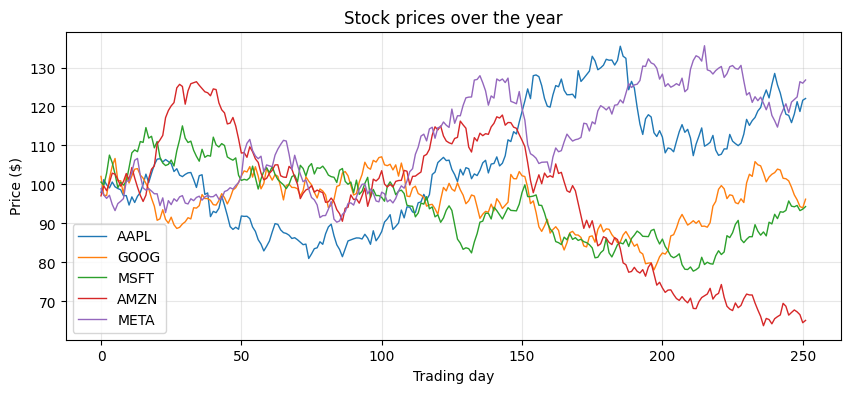

In [12]:
# Line plot — prices over time
plt.figure(figsize=(10, 4))
for i, t in enumerate(tickers):
    plt.plot(prices[:, i], label=t, linewidth=1)
plt.title('Stock prices over the year')
plt.xlabel('Trading day')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

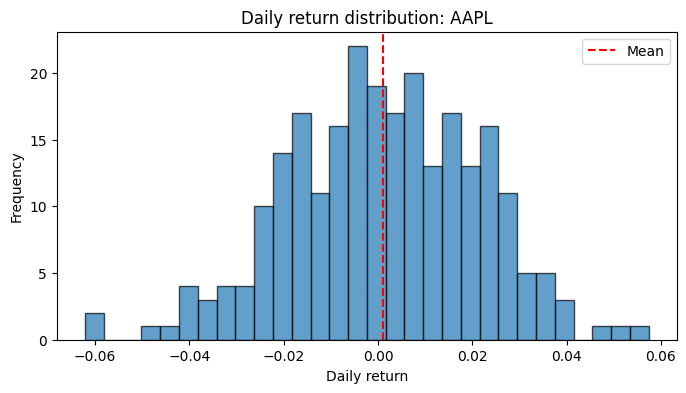

In [13]:
# Histogram — distribution of returns for one stock
plt.figure(figsize=(8, 4))
plt.hist(returns[:, 0], bins=30, alpha=0.7, edgecolor='black')
plt.title(f'Daily return distribution: {tickers[0]}')
plt.xlabel('Daily return')
plt.ylabel('Frequency')
plt.axvline(returns[:, 0].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

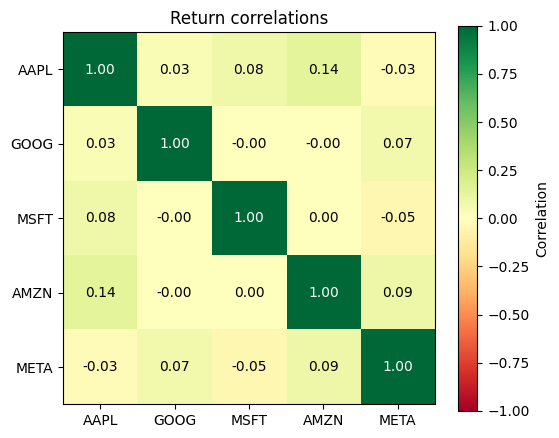

In [14]:
# Heatmap of correlations
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(tickers)), tickers)
plt.yticks(range(len(tickers)), tickers)
plt.title('Return correlations')
for i in range(len(tickers)):
    for j in range(len(tickers)):
        plt.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                 color='white' if abs(corr[i,j]) > 0.5 else 'black')
plt.show()

## 7. Summary

| Task | Method |
|---|---|
| Per-column stats | `arr.mean(axis=0)`, `.std(axis=0)`, etc. |
| Percentiles | `np.percentile(arr, [25, 50, 75], axis=0)` |
| NaN-safe versions | `np.nanmean`, `np.nanstd`, ... |
| Correlation matrix | `np.corrcoef(arr.T)` |
| Dot product | `np.dot(a, b)` or `a @ b` |
| Matrix multiply | `A @ B` |
| Plot from arrays | `plt.plot(arr)`, `plt.hist(arr)`, `plt.imshow(matrix)` |

**Next:** the AI-assisted capstone activity — you'll use ChatGPT to help write analytics code, then critique what it produces.